**Tutorial for using energydiff with the example dataset of GridFM**
==================================================================

This tutorial explains how to use EnergyDiff with a dataset of one node and is build to support covariables. Especially here, the temperature covariable is implemented.

Pre-requisites
-------------
If you haven't already, please download a dataset of power/energy consumption with a hourly resolution and a temperature feature. An example is available in gridfm/streaming_data.ipynb.

In [2]:
# Importing dependencies

import os
import logging

logger = logging.getLogger(__name__)

## Loading data

In [3]:
from pathlib import Path
from opensynth.data_modules.gridfm_data_module import GridFMDataModule
import pytorch_lightning as pl

data_path = Path("../../data/processed/historical/train/data.csv")
stats_path = Path("../../data/processed/historical/train/mean_std.csv")
holdout_data_path = Path("../../data/processed/historical/holdout/data.csv")

# The dataset is small so we define n_training_samples with the maximum number of training samples
batch_size = 64
n_training_samples = 1639

dm = GridFMDataModule(data_path=data_path, stats_path=stats_path, batch_size=batch_size, n_samples=n_training_samples)
dm.setup()

## Diffusion Module

In [ ]:
from opensynth.models.energydiff import diffusion

df_model = diffusion.PLDiffusion1D(
    dim_base=128,
    dim_in=1,
    num_attn_head=4,
    num_decoder_layer=12,
    dim_feedforward=512,
    dropout=0.1,
    learn_variance=False,
    num_timestep=1000,
    model_mean_type=diffusion.ModelMeanType.V,
    model_variance_type=diffusion.ModelVarianceType.FIXED_SMALL,
    loss_type=diffusion.LossType.MSE,
    beta_schedule_type=diffusion.BetaScheduleType.COSINE,
    lr=1e-4,
    ema_update_every=1,
    ema_decay=0.999,
    disable_init_proj=False,
    condition=["temperature"]
)
# Possibility to add the condition "dayofweek" or other features

# Training the model
# Does not support MPS when InitProjection is used.
# cuda works fine.
# suggested to use cuda to train sufficiently and efficiently. 
trainer = pl.Trainer(
    gradient_clip_val=1.0,
    gradient_clip_algorithm="norm",
    max_epochs=50,
    accelerator="auto",
)
# Possibility to change max_epochs to a higher number to train for longer training time
trainer.fit(df_model, dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ diffusion_model │ GaussianDiffusion1D │  3.7 M │ train │     0 │
│ 1 │ ema             │ EMA                 │  7.5 M │ train │     0 │
└───┴─────────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 3.7 M                                                                                            
Non-trainable params: 3.7 M                                                                                        
Total params: 7.5 M                                                                                                
Total estimated model params size (MB): 29                                                                         
Modules in train mode: 635                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=50` reached.


## Track the training dynamics

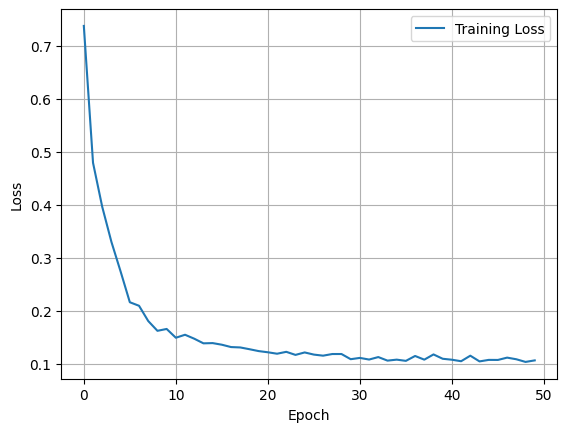

<Figure size 640x480 with 0 Axes>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Directory of checkpoints savings ; logs ; samples savings ; graphs savings 
# Should be iterated to the latest version of the model 
log_dir = "lightning_logs/version_2"

# Plotting the training loss
metrics = pd.read_csv(f"{log_dir}/metrics.csv")
epoch_train_loss = metrics['train_loss_epoch'].dropna().values
# epoch_val_loss = metrics['val_loss'].dropna().values
plt.plot(epoch_train_loss, label='Training Loss')
# plt.plot(epoch_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.plot()
plt.show()
# Optional: Save the plot to a file
plt.savefig(f"{log_dir}/training_loss.png")

## Comparing results

### Generating samples

In [5]:
import torch
import glob
from opensynth.models.energydiff import calibrate

def create_samples(data_module, dir, place, batch_size, num_samples = 200, conditioning = {}):
    # Load checkpoint
    ckpt_path = glob.glob(f"{dir}/checkpoints/*.ckpt")[0]
    df_model = diffusion.PLDiffusion1D.load_from_checkpoint(ckpt_path,)

    # sample
    ema_df_model = df_model.ema.ema_model # GaussianDiffusion1D
    dpm_samples = ema_df_model.dpm_solver_sample(total_num_sample=num_samples, batch_size=batch_size, step=100, shape=(24, 1), conditioning=conditioning)
    dpm_data = data_module.reconstruct_kwh(dpm_samples.squeeze(-1))
    train_data = torch.cat([batch['kwh'] for batch in data_module.train_dataloader()])
    train_data = data_module.reconstruct_kwh(train_data)

    # calibration
    dpm_data_calib = torch.tensor(calibrate.calibrate(train_data, dpm_data).to('cpu'))

    # save samples
    os.makedirs(f"{dir}/{place}", exist_ok=True)
    torch.save(dpm_data.cpu(), f"{dir}/{place}/dpm_data.pt")
    torch.save(dpm_data_calib.cpu(), f"{dir}/{place}/dpm_data_calib.pt")

sampling batch 1/4,                     batch size 64. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:09<00:00, 10.47it/s]


sampling batch 2/4,                     batch size 64. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:10<00:00,  9.24it/s]


sampling batch 3/4,                     batch size 64. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:09<00:00, 10.64it/s]


sampling batch 4/4,                     batch size 8. 


multistep_dpm_solver_update: 100%|██████████| 98/98 [00:03<00:00, 29.55it/s]


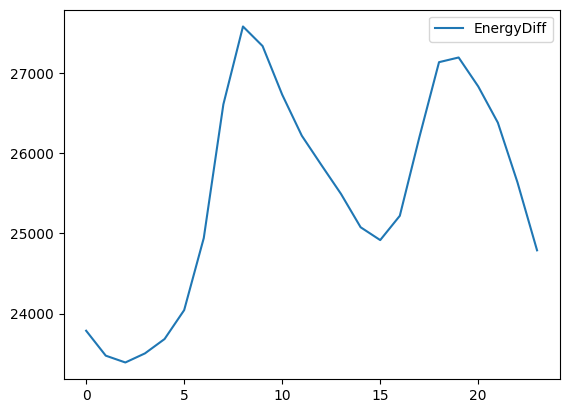

In [8]:
# We create a datamodule based on winter to evaluate if the model can accurately generate samples depending on the different temperatures
# Here we constrained a time_window to winters, but it can be changed to any other time window of interest, or no window at all
eval_data_module = GridFMDataModule(data_path=holdout_data_path, 
                                    stats_path=stats_path, 
                                    batch_size=batch_size, 
                                    n_samples=200,
                                    time_window=[f"10-11-20{xx}/20-03-20{xx+1}" for xx in range(18, 25)])
eval_data_module.setup()

# Configure the folder name to save the samples and plots
place = "winter"

# here the conditioning dictionary only contains the temperature
# dayofweek can be added as a condition if needed, we can extend with other features 
conditioning = {'temperature': torch.tensor(eval_data_module.dataset.temperature, dtype=torch.float32)}
create_samples(dm, log_dir, place, batch_size=batch_size, num_samples=200, conditioning=conditioning)

# We load the non-calibrated samples 
# because we want to see differences between seasons so the post-treatment of the calibration would hide these differences
# for a non conditioned generation, use calibrated samples for a better accuracy
syn_samples = torch.load(f'{log_dir}/{place}/dpm_data.pt')

# Plotting the mean of the samples
plt.plot(syn_samples.mean(dim=0).cpu().numpy(), label='EnergyDiff')
plt.legend()
# Optional: Save the plot to a file
plt.savefig(f"{log_dir}/{place}/samples_mean.png")
plt.show()

In [9]:
# We use all batches of the holdout dataset for evaluation as the dataset is small 
real_data = torch.cat([batch['kwh'] for batch in eval_data_module.train_dataloader()])
real_data = eval_data_module.reconstruct_kwh(real_data)
real_data = torch.clip(real_data, min=0) # Clip min 0 to get rid of negative values

### Comparing mean, 95th quantile, median profiles

In [17]:
from sklearn.metrics import mean_absolute_percentage_error as mape
import numpy as np

def plot_stats(real_data, syn_reconstruct, unit = "MW"):

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18, 3), sharey=True, gridspec_kw={'wspace': 0.05})

    real_mean = real_data.mean(dim=0).detach().numpy()
    syn_mean = syn_reconstruct.mean(dim=0).detach().numpy()
    ax1.plot(real_mean, label=f"real {unit}")
    ax1.plot(syn_mean, label=f"energydiff {unit}")
    ax1.set_title(f"Mean {unit} per half hour")
    ax1.set_xlabel("Settlement Periods")
    ax1.text(0.1, -0.45, "MAPE : " + str(round(mape(real_mean, syn_mean), 3)) 
             + "\nMean error : " + str(round(np.abs(real_mean - syn_mean).mean())) + unit
             + "\nMax error : " + str(round(np.abs(real_mean - syn_mean).max())) + unit, 
                                             transform=ax1.transAxes)
    ax1.legend()

    real_quantile = real_data.quantile(0.95, dim=0).detach().numpy()
    syn_quantile = syn_reconstruct.quantile(0.95, dim=0).detach().numpy()
    ax2.plot(real_quantile, label=f"real {unit}")
    ax2.plot(syn_quantile, label=f"energydiff {unit}")
    ax2.set_title(f"95th Quantile {unit} per half hour")
    ax2.set_xlabel("Settlement Periods")
    ax2.text(0.1, -0.45, "MAPE : " + str(round(mape(real_quantile, syn_quantile), 3)) 
             + "\nMean error : " + str(round(np.abs(real_quantile - syn_quantile).mean())) + unit
             + "\nMax error : " + str(round(np.abs(real_quantile - syn_quantile).max())) + unit, 
                                             transform=ax2.transAxes)
    ax2.legend()

    real_5quantile = real_data.quantile(0.05, dim=0).detach().numpy()
    syn_5quantile = syn_reconstruct.quantile(0.05, dim=0).detach().numpy()
    ax3.plot(real_5quantile, label=f"real {unit}")
    ax3.plot(syn_5quantile, label=f"energydiff {unit}")
    ax3.set_title(f"5th Quantile {unit} per half hour")
    ax3.set_xlabel("Settlement Periods")
    ax3.text(0.1, -0.45, "MAPE : " + str(round(mape(real_5quantile, syn_5quantile), 3)) 
                + "\nMean error : " + str(round(np.abs(real_5quantile - syn_5quantile).mean())) + unit
                + "\nMax error : " + str(round(np.abs(real_5quantile - syn_5quantile).max())) + unit, 
                                                transform=ax3.transAxes)
    ax3.legend()

    real_median = real_data.quantile(0.5, dim=0).detach().numpy()
    syn_median = syn_reconstruct.quantile(0.5, dim=0).detach().numpy()
    ax4.plot(real_median, label=f"real {unit}")
    ax4.plot(syn_median, label=f"energydiff {unit}")
    ax4.set_title(f"Median {unit} per half hour")
    ax4.set_xlabel("Settlement Periods")
    ax4.text(0.1, -0.45, "MAPE : " + str(round(mape(real_median, syn_median), 3))
                + "\nMean error : " + str(round(np.abs(real_median - syn_median).mean())) + unit
                + "\nMax error : " + str(round(np.abs(real_median - syn_median).max())) + unit, 
                                                transform=ax4.transAxes)
    ax4.legend()

    fig.text(0.08, 0.5, unit, va='center', rotation='vertical')
    fig.tight_layout()
    
    return fig

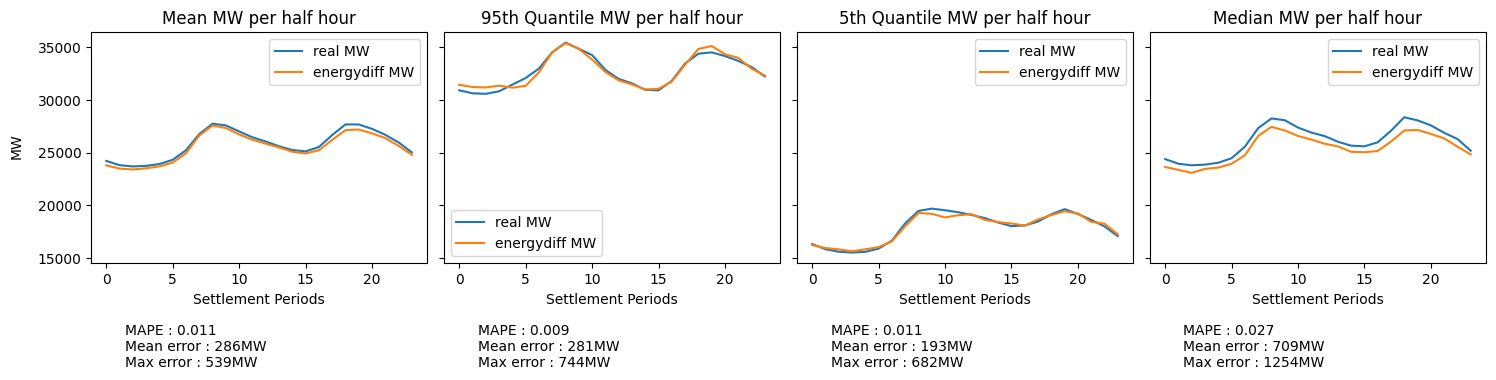

In [18]:
fig = plot_stats(real_data, syn_samples)
# Optional: Save the plot to a file
plt.savefig(f"{log_dir}/{place}/stats_plot.png", bbox_inches='tight')
plt.show()

### PCA and TSNE Distribution

In [12]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def train_pca_and_tsne(real_data, syn_reconstruct):
    pca = PCA(n_components=2)
    tsne = TSNE(n_components=2, perplexity=min(30, len(real_data)))

    pca.fit(real_data.detach().numpy())
    pca_real = pca.transform(real_data.detach().numpy())
    pca_syn = pca.transform(syn_reconstruct.detach().numpy())

    tsne_input = np.concatenate([real_data.detach().numpy(), syn_reconstruct.detach().numpy()])
    tsne_results = tsne.fit_transform(tsne_input)
    tsne_real = tsne_results[:len(real_data)]
    tsne_syn = tsne_results[len(real_data):]

    return pca_real, pca_syn, tsne_real, tsne_syn


def plot_pca_tsne(pca_real, pca_syn, tsne_real, tsne_syn, unit = "MW"):
    fig, (ax_pca, ax_tsne) = plt.subplots(1, 2, figsize=(12, 4))

    ax_pca.scatter(pca_real[:, 0], pca_real[:, 1], label=f"real {unit}", s=0.3, alpha=0.5)
    ax_pca.scatter(pca_syn[:, 0], pca_syn[:, 1], label=f"energydiff {unit}", s=0.3, alpha=0.5)
    ax_pca.set_title("PCA")
    ax_pca.set_xlabel("PCA 1")
    ax_pca.set_ylabel("PCA 2")
    ax_pca.legend()

    ax_tsne.scatter(tsne_real[:, 0], tsne_real[:, 1], label=f"real {unit}", s=0.3, alpha=0.5)
    ax_tsne.scatter(tsne_syn[:, 0], tsne_syn[:, 1], label=f"energydiff {unit}", s=0.3, alpha=0.5)
    ax_tsne.set_title("TSNE")
    ax_tsne.set_xlabel("TSNE 1")
    ax_tsne.set_ylabel("TSNE 2")
    ax_tsne.legend()
    
    return fig

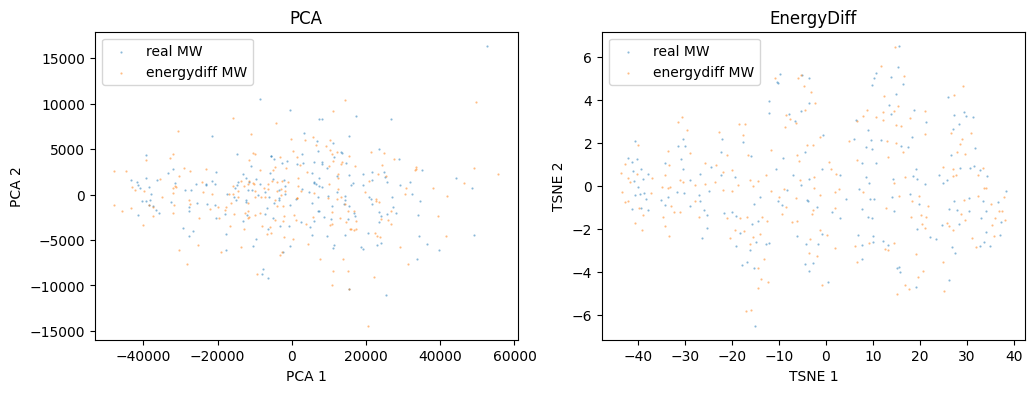

In [13]:
a1, a2, a3, a4 = train_pca_and_tsne(real_data, syn_samples)
fig = plot_pca_tsne(a1, a2, a3, a4)
plt.title("EnergyDiff")
# Optional: Save the plot to a file
plt.savefig(f"{log_dir}/{place}/pca_tsne_plot.png")
plt.show()

### Distribution metrics

In [14]:
from scipy.stats import entropy
from scipy.stats import wasserstein_distance
from scipy.stats import kstest

kl_div = []
wasserstein_dist = []
ks_dist = []

for i in range(real_data.shape[1]):
    real_hist, _ = np.histogram(real_data[:, i], bins=500)
    syn_hist, _ = np.histogram(syn_samples[:, i], bins=500)
    kl_div.append(float(round(entropy(real_hist + 1e-10, syn_hist + 1e-10), 3)))
    wasserstein_dist.append(float(round(wasserstein_distance(real_data[:, i], syn_samples[:, i]), 3)))
    ks_dist.append(float(round(kstest(real_data[:, i], syn_samples[:, i]).statistic, 3)))


dist = (f"KL Divergence (for each settlement period) : {kl_div}\n"
        + f"Min ; Max ; Mean : {min(kl_div), max(kl_div), float(round(np.mean(kl_div), 3))} \n \n"
        + f"Wasserstein Distance (for each settlement period) : {wasserstein_dist}\n"
        + f"Min ; Max ; Mean : {min(wasserstein_dist), max(wasserstein_dist), float(round(np.mean(wasserstein_dist), 3))}\n \n"
        + f"KS Distance (for each settlement period) : {ks_dist}\n"
        + f"Min ; Max ; Mean : {min(ks_dist), max(ks_dist), float(round(np.mean(ks_dist), 3))}\n")

print(dist)
#Optional: Save the metrics to a text file
with open(f"{log_dir}/{place}/distance.txt", "w") as f:
    f.write(dist)

KL Divergence (for each settlement period) : [14.907, 13.597, 14.209, 14.874, 14.063, 14.725, 13.778, 13.952, 12.841, 14.532, 12.104, 13.501, 12.907, 12.636, 12.835, 13.081, 12.891, 13.178, 14.731, 12.919, 13.084, 13.411, 13.547, 12.668]
Min ; Max ; Mean : (12.104, 14.907, 13.54) 
 
Wasserstein Distance (for each settlement period) : [494.898, 453.235, 381.559, 310.477, 320.656, 349.031, 359.034, 323.248, 301.479, 363.261, 360.573, 328.096, 307.072, 266.069, 315.274, 339.951, 417.587, 547.561, 619.343, 588.929, 535.784, 451.861, 451.418, 330.942]
Min ; Max ; Mean : (266.069, 619.343, 396.556)
 
KS Distance (for each settlement period) : [0.089, 0.086, 0.078, 0.06, 0.06, 0.072, 0.074, 0.081, 0.075, 0.101, 0.077, 0.08, 0.081, 0.076, 0.072, 0.079, 0.081, 0.123, 0.111, 0.126, 0.106, 0.084, 0.079, 0.059]
Min ; Max ; Mean : (0.059, 0.126, 0.084)

